# Credit Default Prediction with Deep Learning

A binary-classification project that predicts whether a credit-card client will default in the next month.

**Main focus:** build a clean ANN workflow, handle class imbalance, control overfitting with EarlyStopping, and evaluate the minority/default class with metrics beyond accuracy.

**Dataset:** UCI Machine Learning Repository — *Default of Credit Card Clients*  
https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

## 1. Imports and reproducibility

This notebook is designed for **Python 3.12** and **TensorFlow 2.21**.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")

## 2. Load the dataset

Download and extract `default of credit card clients.xls` from the UCI link above, then place the `.xls` file in the same folder as this notebook.

In [2]:
DATA_PATH = Path("default of credit card clients.xls")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Download 'default of credit card clients.xls' "
        "from the UCI dataset page and place it next to this notebook."
    )

df = pd.read_excel(DATA_PATH, header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Data quality checks

In [3]:
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

df.info()

Shape: (30000, 25)
Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2        

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## 4. Target distribution

The target is imbalanced, so accuracy alone is not enough. We will also track ROC-AUC, precision, recall, and F1-score for the default class (`1`).

In [5]:
TARGET = "default payment next month"

target_counts = df[TARGET].value_counts().sort_index()
target_share = df[TARGET].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "share": target_share
})

target_summary

,count,share
default payment next month,,
0,23364,0.7788
1,6636,0.2212


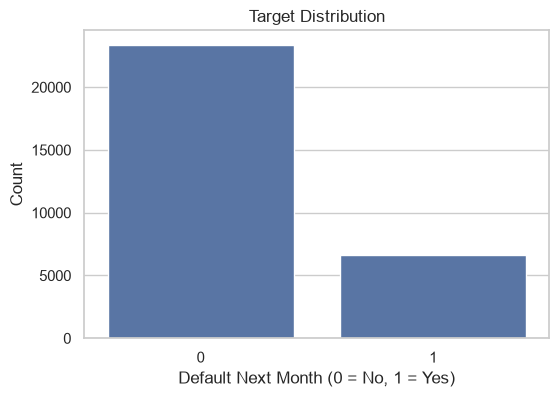

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Target Distribution")
plt.xlabel("Default Next Month (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

## 5. Features and train/validation/test split

`ID` is removed because it is only an identifier.

The data is split into:
- **64% train**
- **16% validation**
- **20% test**

The validation set is created **before preprocessing** so preprocessing is fitted only on the training data. This avoids validation leakage.

In [7]:
X = df.drop(columns=["ID", TARGET])
y = df[TARGET].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED,
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (19200, 23) (19200,)
Validation: (4800, 23) (4800,)
Test: (6000, 23) (6000,)


## 6. Preprocessing

`SEX`, `EDUCATION`, and `MARRIAGE` are coded categorical variables, so they are one-hot encoded.

The remaining features are scaled with `StandardScaler`. The preprocessor is fitted **only on the training set**.

In [8]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

print("Processed train shape:", X_train_scaled.shape)

Processed train shape: (19200, 33)


## 7. Class weights

The default class is the minority class. Balanced class weights make mistakes on class `1` more costly during training.

In [9]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

class_weight_dict = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

class_weight_dict

{0: 0.6420116364609109, 1: 2.2604191193783847}

## 8. Model builder

In [10]:
def build_ann(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model

## 9. Baseline ANN

This model is trained without class weights. It is useful as a reference point for the effect of imbalance handling.

In [11]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

baseline_model = build_ann(X_train_scaled.shape[1])

history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1,
)

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 444us/step - accuracy: 0.7862 - auc: 0.6787 - loss: 0.5021 - val_accuracy: 0.8154 - val_auc: 0.7401 - val_loss: 0.4560
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step - accuracy: 0.8164 - auc: 0.7427 - loss: 0.4518 - val_accuracy: 0.8146 - val_auc: 0.7567 - val_loss: 0.4476
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step - accuracy: 0.8182 - auc: 0.7563 - loss: 0.4439 - val_accuracy: 0.8188 - val_auc: 0.7637 - val_loss: 0.4441
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step - accuracy: 0.8211 - auc: 0.7646 - loss: 0.4391 - val_accuracy: 0.8177 - val_auc: 0.7674 - val_loss: 0.4410
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - accuracy: 0.8191 - auc: 0.7670 - loss: 0.4377 - val_accuracy: 0.8198 - val_auc: 0.7688 - val_loss: 0.4396
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step - accuracy: 0.8217 - auc: 0.7749 - loss: 0.4322 - val_accuracy: 0.8198 - val_auc: 0.7702 - val_loss: 0.4388
Epoch 7/20
600/600 ━━━━━━━━━

In [12]:
baseline_val_prob = baseline_model.predict(X_val_scaled, verbose=0).ravel()
baseline_val_pred = (baseline_val_prob >= 0.50).astype(int)

print("Baseline validation ROC-AUC:", round(roc_auc_score(y_val, baseline_val_prob), 4))
print(classification_report(y_val, baseline_val_pred, digits=3))

Baseline validation ROC-AUC: 0.7696
              precision    recall  f1-score   support

           0      0.837     0.951     0.890      3738
           1      0.668     0.349     0.459      1062

    accuracy                          0.818      4800
   macro avg      0.753     0.650     0.675      4800
weighted avg      0.800     0.818     0.795      4800



## 10. Final weighted ANN with EarlyStopping

EarlyStopping monitors validation ROC-AUC and restores the best weights instead of simply keeping the last epoch.

In [13]:
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
)

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

final_model = build_ann(X_train_scaled.shape[1])

history_final = final_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 452us/step - accuracy: 0.6921 - auc: 0.7186 - loss: 0.6131 - val_accuracy: 0.7490 - val_auc: 0.7473 - val_loss: 0.6159
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 294us/step - accuracy: 0.7635 - auc: 0.7519 - loss: 0.5861 - val_accuracy: 0.7598 - val_auc: 0.7565 - val_loss: 0.6081
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step - accuracy: 0.7644 - auc: 0.7661 - loss: 0.5746 - val_accuracy: 0.7623 - val_auc: 0.7613 - val_loss: 0.5922
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step - accuracy: 0.7666 - auc: 0.7708 - loss: 0.5708 - val_accuracy: 0.7585 - val_auc: 0.7643 - val_loss: 0.5880
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step - accuracy: 0.7658 - auc: 0.7775 - loss: 0.5664 - val_accuracy: 0.7571 - val_auc: 0.7658 - val_loss: 0.5820
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step - accuracy: 0.7635 - auc: 0.7762 - loss: 0.5663 - val_accuracy: 0.7596 - val_auc: 0.7657 - val_loss: 0.5797
Epoch 7/50
600/600 ━━━━━━━━━

## 11. Training curves

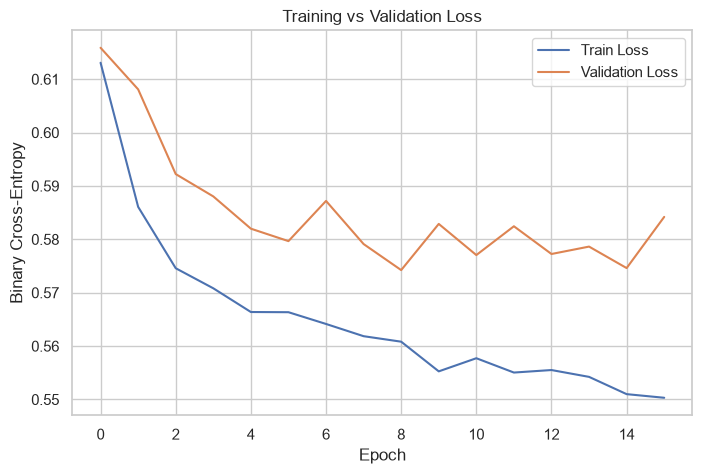

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_final.history["loss"], label="Train Loss")
plt.plot(history_final.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

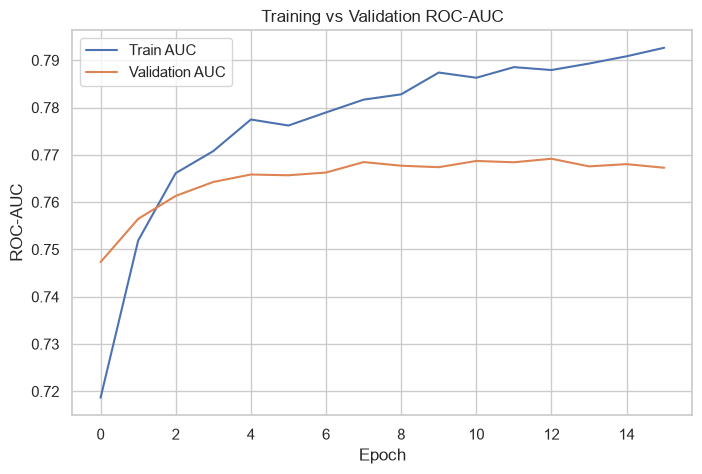

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_final.history["auc"], label="Train AUC")
plt.plot(history_final.history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Training vs Validation ROC-AUC")
plt.legend()
plt.show()

## 12. Threshold selection on validation data

The classification threshold is selected on the **validation set**, not the test set.

Here we choose the threshold that maximizes F1-score on validation data. In a real credit-risk setting, the threshold should be chosen from business costs, risk appetite, and the relative cost of false negatives vs false positives.

In [16]:
val_prob = final_model.predict(X_val_scaled, verbose=0).ravel()

precision, recall, thresholds = precision_recall_curve(y_val, val_prob)

f1_values = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-12)
)

best_idx = int(np.argmax(f1_values))
selected_threshold = float(thresholds[best_idx])

print("Selected threshold:", round(selected_threshold, 4))
print("Validation F1:", round(float(f1_values[best_idx]), 4))
print("Validation Precision:", round(float(precision[best_idx]), 4))
print("Validation Recall:", round(float(recall[best_idx]), 4))

Selected threshold: 0.595
Validation F1: 0.536
Validation Precision: 0.5263
Validation Recall: 0.5461


## 13. Final evaluation on the untouched test set

The test set is used only after model development and threshold selection are complete.

In [17]:
test_prob = final_model.predict(X_test_scaled, verbose=0).ravel()
test_pred = (test_prob >= selected_threshold).astype(int)

results = pd.Series({
    "Accuracy": accuracy_score(y_test, test_pred),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "Precision (default=1)": precision_score(y_test, test_pred),
    "Recall (default=1)": recall_score(y_test, test_pred),
    "F1 (default=1)": f1_score(y_test, test_pred),
    "Threshold": selected_threshold,
})

results.round(4)

Accuracy                 0.7893
ROC-AUC                  0.7698
Precision (default=1)    0.5229
Recall (default=1)       0.5411
F1 (default=1)           0.5319
Threshold                0.5950
dtype: float64

In [18]:
print(classification_report(y_test, test_pred, digits=3))

              precision    recall  f1-score   support

           0      0.868     0.860     0.864      4673
           1      0.523     0.541     0.532      1327

    accuracy                          0.789      6000
   macro avg      0.696     0.700     0.698      6000
weighted avg      0.792     0.789     0.791      6000



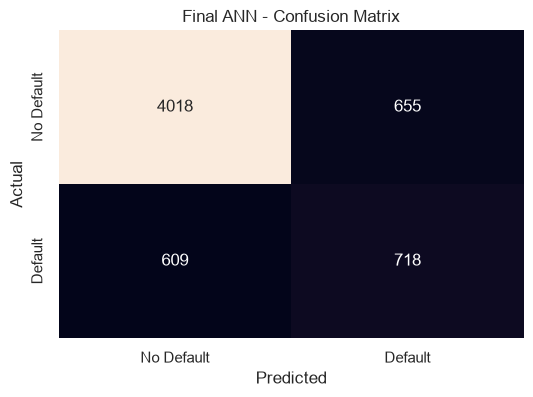

In [19]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final ANN - Confusion Matrix")
plt.show()

## 14. ROC and Precision-Recall curves

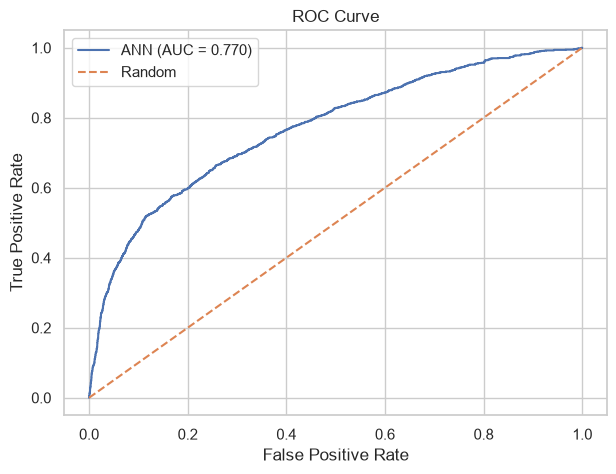

In [20]:
fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ANN (AUC = {roc_auc_score(y_test, test_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

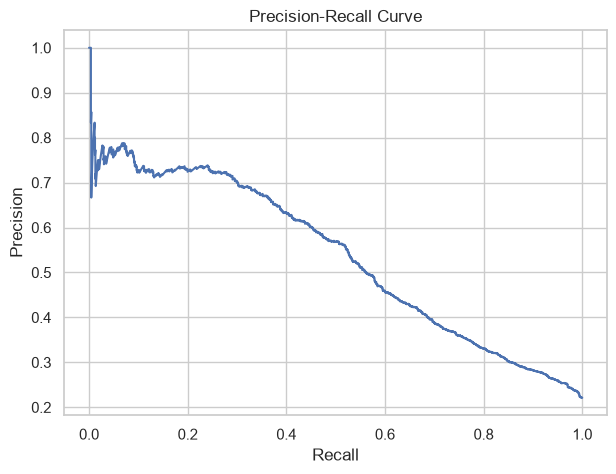

In [21]:
pr_precision, pr_recall, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(pr_recall, pr_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## 15. Save model artifacts (optional)

Uncomment this cell if you want local deployment artifacts. They are excluded from Git by default in the included `.gitignore`.

In [22]:
# from joblib import dump
#
# Path("artifacts").mkdir(exist_ok=True)
# final_model.save("artifacts/credit_default_ann.keras")
# dump(preprocessor, "artifacts/preprocessor.joblib")

## Conclusion

This project demonstrates an end-to-end deep-learning workflow for an imbalanced credit-default classification problem:

- stratified train/validation/test splitting;
- leakage-safe preprocessing;
- one-hot encoding of coded nominal variables;
- feature scaling for neural-network training;
- class weighting for imbalance;
- EarlyStopping based on validation ROC-AUC;
- threshold selection on validation data rather than the test set;
- final evaluation with ROC-AUC, precision, recall, F1-score, and a confusion matrix.

The most important lesson is that **accuracy alone is not enough for imbalanced credit-risk problems**. Minority-class recall and precision must be evaluated explicitly.